In [1]:
import pandas as pd
import numpy as np
import torch
import strats
import datetime
import os
import pickle
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score, accuracy_score, brier_score_loss, precision_recall_curve
from sklearn.model_selection import ParameterGrid
from expl_perf_drop.explainers import CGExplainerDR
from expl_perf_drop.utils import Graph
from tqdm.notebook import tqdm
tqdm.pandas()

print(datetime.datetime.now())


Initializing package . . . 😘
2025-03-09 21:50:08.587348


# Data processing

In [2]:
def compute_trimmed_stats(values: pd.Series, low_pct: float, high_pct: float):
    """
    values: 해당 그룹의 value Series
    low_pct, high_pct: 잘라낼 분위수 (예: 0.01, 0.99)
    
    반환: (trimmed_mean, trimmed_std)
    """
    lower_bound = values.quantile(low_pct)
    upper_bound = values.quantile(high_pct)
    trimmed = values[(values >= lower_bound) & (values <= upper_bound)]
    return trimmed.mean(), trimmed.std()

def calculate_all_stats(df: pd.DataFrame):
    # 결과를 담을 리스트
    results = []

    # itemid별로 그룹화
    grouped = df.groupby('itemid')

    for item_id, group in grouped:
        vals = group['value']

        # 1) 전체(아웃라이어 제거 없음) 평균/표준편차
        orig_mean = vals.mean()
        orig_std  = vals.std()

        # 2) 상하위 1% 제거
        mean_1pct, std_1pct = compute_trimmed_stats(vals, 0.01, 0.99)

        # 3) 상하위 3% 제거
        mean_3pct, std_3pct = compute_trimmed_stats(vals, 0.03, 0.97)

        # 4) 상하위 5% 제거
        mean_5pct, std_5pct = compute_trimmed_stats(vals, 0.05, 0.95)

        # 결과 한 줄로 정리
        results.append({
            'itemid': item_id,
            'orig_mean': orig_mean,
            'orig_std': orig_std,
            'mean_1pct': mean_1pct,
            'std_1pct': std_1pct,
            'mean_3pct': mean_3pct,
            'std_3pct': std_3pct,
            'mean_5pct': mean_5pct,
            'std_5pct': std_5pct
        })

    # 리스트를 DataFrame으로
    df_stats = pd.DataFrame(results)
    return df_stats

def agg_window_fast(window_df: pd.DataFrame):
    """
    window_df: columns=['offset','itemid','value']
    pivot -> shape=(#unique offset, #unique itemid)
    Then for each column(itemid), compute stats (mean, max, ...)
    """
    if window_df.empty:
        return {}

    pivoted = window_df.pivot(index='offset', columns='itemid', values='value')
    # pivoted: offset x itemid
    # col별 => mean, max, min, ...
    stats_dict = {}
    col_names = pivoted.columns
    means = pivoted.mean(axis=0)
    maxs  = pivoted.max(axis=0)
    mins  = pivoted.min(axis=0)
    stds  = pivoted.std(axis=0)
    meds  = pivoted.median(axis=0)
    q25s  = pivoted.quantile(0.25, axis=0)
    q75s  = pivoted.quantile(0.75, axis=0)
    counts = pivoted.count(axis=0)

    for item in col_names:
        # skip if all NaN?
        # or do if counts[item]==0 => skip
        rng = maxs[item] - mins[item] if counts[item]>0 else np.nan
        stats_dict[f'{item}_mean'] = means[item]
        stats_dict[f'{item}_max']  = maxs[item]
        stats_dict[f'{item}_min']  = mins[item]
        stats_dict[f'{item}_std']  = stds[item]
        stats_dict[f'{item}_median'] = meds[item]
        stats_dict[f'{item}_q25'] = q25s[item]
        stats_dict[f'{item}_q75'] = q75s[item]
        stats_dict[f'{item}_range'] = rng
        stats_dict[f'{item}_count'] = counts[item]

    return stats_dict


def get_clip_bounds_from_train(train_df: pd.DataFrame, binary_itemids: set, trim_percentile=0.01):
    """
    Train 데이터로부터 각 itemid별 (lower, upper) clip bound를 계산.
    binary_itemids는 trimming 제외.
    
    반환:
      clip_bounds: dict(itemid -> (lower, upper))
    """

    clip_bounds = {}
    for item_id, grp in train_df.groupby('itemid'):
        if item_id in binary_itemids:
            continue
        lower = grp['value'].quantile(trim_percentile)
        upper = grp['value'].quantile(1 - trim_percentile)
        clip_bounds[item_id] = (lower, upper)
    
    return clip_bounds

def apply_clip_bounds(df: pd.DataFrame, binary_itemids: set, clip_bounds: dict):
    """
    df를 itemid별로 나누어, clip_bounds가 있는 경우 그 범위 내로 trimming.
    binary itemid는 trimming 없이 그대로.
    """

    trimmed_parts = []
    for item_id, grp in df.groupby('itemid'):
        if item_id in binary_itemids:
            trimmed_parts.append(grp)
        else:
            if item_id in clip_bounds:
                l, u = clip_bounds[item_id]
                clipped = grp[(grp['value']>=l)&(grp['value']<=u)]
                trimmed_parts.append(clipped)
            else:
                trimmed_parts.append(grp)
    return pd.concat(trimmed_parts, ignore_index=True)


def aggregate_time_series_features_mor_stepwise(
    df: pd.DataFrame,
    outcome_df: pd.DataFrame,
    obs_window: int = 48*60,   # 기본 48시간
):
    """
    1) df ([hadm_id, offset, itemid, value])에 대해
       각 hadm_id별로 첫 48시간(=obs_window) 데이터를 사용하여 통계 요약을 진행.
       - 윈도우는 [0, obs_window]로 고정 (query_time = obs_window)
       - 윈도우 내 itemid별 통계를 계산 (mean, max, min 등)
    2) outcome_df ([hadm_id, death_offset])를 이용해 death 라벨링:
       - death_offset이 윈도우 내 ([0, obs_window]) 또는 그 이전이면 해당 샘플은 skip
       - (B) death_offset이 존재하면 → death_label=1, 없으면 0

    Returns:
      DataFrame: 각 (hadm_id, query_time)별로 itemid 통계와 death_label이 열로 추가된 DataFrame.
    """
    # ------------------------
    # 0) 데이터 복사 및 첫 48시간 데이터만 선택
    # ------------------------
    df_filtered = df.copy()
    # 각 환자에 대해 offset이 obs_window 이하인 데이터만 사용
    df_filtered = df_filtered[df_filtered['offset'] <= obs_window].copy()

    # ------------------------
    # C) outcome_df -> dict {hadm_id: death_offset}
    # ------------------------
    hadm2death = outcome_df.set_index('hadm_id')['death_offset'].to_dict()

    # ------------------------
    # E) 각 hadm_id별로 첫 48시간 윈도우에 대해 통계 계산 및 death 라벨링
    # ------------------------
    results = []
    hadm_groups = df_filtered.groupby('hadm_id')
    for hadm_id, group in tqdm(hadm_groups, desc="[aggregate aki stepwise]"):
        if group.empty:
            continue

        # 해당 환자의 최대 offset (모두 obs_window 이하)
        max_offset = group['offset'].max()
        # 고정 query_time: obs_window (즉, 첫 48시간)
        qtime = obs_window
        win_start = 0
        win_end = obs_window

        # 관찰 윈도우 내 데이터 (전체 0~obs_window)
        obs_window_df = group.copy()
        if obs_window_df.empty or obs_window_df.shape[0] < 10:
            continue

        # death_offset (outcome_df에서 해당 환자의 값; 없으면 NaN)
        death_offset = hadm2death.get(hadm_id, np.nan)

        # (A) 관찰 윈도우 내 또는 그 이전에 death_offset이 존재하면 sample skip
        skip_sample = False
        if not np.isnan(death_offset):
            if (death_offset > win_start) and (death_offset <= win_end):
                skip_sample = True
            if death_offset < win_start:
                skip_sample = True
        if skip_sample:
            continue

        # (B) 여기서는 존재하기만 하면 label=1
        death_label = 0
        if not np.isnan(death_offset):
            death_label = 1

        # 윈도우 내 offset 재조정 (이미 0부터 시작)
        obs_window_df['offset'] = obs_window_df['offset'] - win_start

        # itemid별 통계 계산 (외부 함수 agg_window_fast 사용)
        row_dict = {
            'hadm_id': hadm_id,
            'query_time': qtime,
            'outcome': death_label
        }
        stats_dict = agg_window_fast(obs_window_df[['offset','itemid','value']])
        row_dict.update(stats_dict)
        results.append(row_dict)

    # ------------------------
    # F) 결과 DataFrame 생성 및 정렬
    # ------------------------
    final_df = pd.DataFrame(results)
    if final_df.empty:
        print("[aggregate_time_series_features_aki_stepwise] No data generated.")
        return final_df

    base_cols = ['hadm_id', 'query_time', 'outcome']
    other_cols = [c for c in final_df.columns if c not in base_cols]
    final_cols = base_cols + other_cols
    final_df = final_df[final_cols]

    return final_df



In [3]:
# Use Age, gender, height

mimic_static = pd.read_feather('mimic_data_static.feather')
# Gender is 1 for male, 0 for female
mimic_static['gender'] = (mimic_static['gender'] == 'M').astype(int)

# Change height to cm (*2.54)
mimic_static['height'] = mimic_static['height'] * 2.54




# 저장
with open('item_dict_total.pkl', 'rb') as f:
    item_dict_total = pickle.load(f)

# (1) clip_bounds
with open('clip_bounds_48_mimic.pkl', 'rb') as f:
    clip_bounds_all = pickle.load(f)

reverse_item_dict = {v: k for k, v in item_dict_total.items()}

# 새로운 dict를 생성하여, clip_bounds_all의 key를 원래 변수명으로 변경합니다.
clip_bounds = {}
for encoded_key, bounds in clip_bounds_all.items():
    original_name = reverse_item_dict.get(encoded_key, encoded_key)  # 매핑이 없으면 그대로 사용
    clip_bounds[original_name] = bounds

def process_static(static):
    # Treat only in-hospital death
    static.loc[static['hospital_expire_flag'] == 0, 'deathtime'] = None
    print(len(static[static['outtime'] >= static['deathtime']]))
    static = static.loc[:,['hadm_id', 'deathtime']]
    static = static.rename(columns={'hadm_id': 'hadm_id', 'deathtime' : 'death_offset'})
    unique_static_ids = static['hadm_id'].unique()
    return static, unique_static_ids

mimic_outcome, mimic_ids = process_static(mimic_static)

data_vital = pd.read_feather('mimic_data_vital.feather').rename(columns={'valuenum' : 'value'})
data_lab = pd.read_feather('mimic_data_lab.feather').rename(columns={'valuenum' : 'value'})
data_treatment = pd.read_feather('mimic_data_treatment.feather').rename(columns={'valuenum' : 'value'})

data = pd.concat([data_vital, data_lab, data_treatment])

# Factorize the 'item' column and get the mapping
encoded_total, actual_class_total = pd.factorize(data['itemid'])
# data.loc[:,'itemid'] = encoded_total.astype(int)
# data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

data = data.dropna(subset=['value'])
data_stats = calculate_all_stats(data)


# 재현성 유지를 위해 seed를 고정하고 섞습니다.
np.random.seed(9871)
np.random.shuffle(mimic_ids)

train_size = int(len(mimic_ids) * 0.6)
valid_size = int(len(mimic_ids) * 0.8)

train_hadm_ids = mimic_ids[:train_size]
valid_hadm_ids = mimic_ids[train_size:valid_size]
test_hadm_ids = mimic_ids[valid_size:]

train_final_ids = train_hadm_ids
valid_final_ids = valid_hadm_ids
test_final_ids = test_hadm_ids

# (D) 최종 DF
train_df = data[data['hadm_id'].isin(train_final_ids)].copy().sort_values(by=['hadm_id']).reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().sort_values(by=['hadm_id']).reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().sort_values(by=['hadm_id']).reset_index(drop=True)

train_outcome_df = mimic_outcome[mimic_outcome['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_outcome_df = mimic_outcome[mimic_outcome['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_outcome_df = mimic_outcome[mimic_outcome['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)

# 1) 이진 변수는 'Train'에서 식별(또는 전체 df)
train_binary_itemids = set()
for item_id, grp in train_df.groupby('itemid'):
    uniq = set(grp['value'].dropna().unique())
    if uniq.issubset({0,1}):
        train_binary_itemids.add(item_id)
print("[binary item ids]", train_binary_itemids)


# 3) Train/Valid/Test 각각 trimming
train_df_trim = apply_clip_bounds(train_df, train_binary_itemids, clip_bounds)
valid_df_trim = apply_clip_bounds(valid_df, train_binary_itemids, clip_bounds)
test_df_trim  = apply_clip_bounds(test_df,  train_binary_itemids, clip_bounds)

train_df = aggregate_time_series_features_mor_stepwise(
    train_df_trim, train_outcome_df,
    obs_window=48*60,
).sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)
train_df = train_df.merge(mimic_static[['hadm_id', 'age', 'height', 'gender']], how='left', on='hadm_id')

valid_df = aggregate_time_series_features_mor_stepwise(
    valid_df_trim, valid_outcome_df,
    obs_window=48*60,
).sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)
valid_df = valid_df.merge(mimic_static[['hadm_id', 'age', 'height', 'gender']], how='left', on='hadm_id')


test_df = aggregate_time_series_features_mor_stepwise(
    test_df_trim, test_outcome_df,
    obs_window=48*60,
).sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)
test_df = test_df.merge(mimic_static[['hadm_id', 'age', 'height', 'gender']], how='left', on='hadm_id')


valid_df = valid_df.reindex(columns=train_df.columns, fill_value=np.nan)
test_df  = test_df.reindex(columns=train_df.columns, fill_value=np.nan)

print(datetime.datetime.now())

21
[binary item ids] {'a_drug', 'v', 'b', 'fluid', 'ventilator', 'a10', 'antibiotics', 'c01', 'c_else', 'l', 'm', 'n', 'a_supplements', 'h', 'r'}


[aggregate aki stepwise]:   0%|          | 0/27159 [00:00<?, ?it/s]

[aggregate aki stepwise]:   0%|          | 0/9053 [00:00<?, ?it/s]

[aggregate aki stepwise]:   0%|          | 0/9054 [00:00<?, ?it/s]

2025-03-09 21:54:59.963711


In [4]:
# eICU
# embs_varwise
# Less samples because
# Use Age, gender, height

eicu_static = pd.read_feather('eicu_data_static.feather')

eicu_static = eicu_static.rename(columns={'admissionheight' : 'height', 'patientunitstayid' : 'hadm_id'})
# Gender is 1 for male, 0 for female
eicu_static['gender'] = (eicu_static['gender'] == 'Male').astype(int)

def process_static(static):
    # Treat only in-hospital death
    static.loc[static['unitdischargestatus'] == 'Alive', 'unitdischargeoffset'] = None
    static = static.loc[:,['hadm_id', 'unitdischargeoffset']]
    static = static.rename(columns={'hadm_id': 'hadm_id', 'unitdischargeoffset' : 'death_offset'})
    unique_static_ids = static['hadm_id'].unique()
    return static, unique_static_ids

eicu_outcome, eicu_ids = process_static(eicu_static)



data_vital_eicu = pd.read_feather('eicu_data_vital.feather').rename(columns={'valuenum' : 'value', 'patientunitstayid' : 'hadm_id'})
data_lab_eicu = pd.read_feather('eicu_data_lab.feather').rename(columns={'valuenum' : 'value', 'patientunitstayid' : 'hadm_id'})
data_treatment_eicu = pd.read_feather('eicu_data_treatment.feather').rename(columns={'valuenum' : 'value', 'patientunitstayid' : 'hadm_id'})

data_eicu = pd.concat([data_vital_eicu, data_lab_eicu, data_treatment_eicu])

data_eicu = data_eicu.dropna(subset=['value'])
data_eicu_stats = calculate_all_stats(data_eicu)

np.random.shuffle(eicu_ids)

# 예: 80%를 train, 나머지를 valid로 사용
train_size = int(len(eicu_ids) * 0.8)
valid_size = int(len(eicu_ids) * 1.0)
train_hadm_ids = eicu_ids[:train_size]
valid_hadm_ids = eicu_ids[train_size:]
test_hadm_ids = eicu_ids

train_final_ids = train_hadm_ids
valid_final_ids = valid_hadm_ids
test_final_ids = test_hadm_ids


# (D) 최종 DF_eicu
train_df_eicu = data_eicu[data_eicu['hadm_id'].isin(train_final_ids)].copy().sort_values(by=['hadm_id']).reset_index(drop=True)
valid_df_eicu = data_eicu[data_eicu['hadm_id'].isin(valid_final_ids)].copy().sort_values(by=['hadm_id']).reset_index(drop=True)
test_df_eicu = data_eicu[data_eicu['hadm_id'].isin(test_final_ids)].copy().sort_values(by=['hadm_id']).reset_index(drop=True)

train_outcome_df_eicu = eicu_outcome[eicu_outcome['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_outcome_df_eicu = eicu_outcome[eicu_outcome['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_outcome_df_eicu = eicu_outcome[eicu_outcome['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)

# 1) 이진 변수는 'Train'에서 식별(또는 전체 df_eicu)
train_binary_itemids = set()
for item_id, grp in train_df_eicu.groupby('itemid'):
    uniq = set(grp['value'].dropna().unique())
    if uniq.issubset({0,1}):
        train_binary_itemids.add(item_id)
print("[binary item ids]", train_binary_itemids)


# 3) Train/Valid/Test 각각 trimming
train_df_eicu_trim = apply_clip_bounds(train_df_eicu, train_binary_itemids, clip_bounds)
valid_df_eicu_trim = apply_clip_bounds(valid_df_eicu, train_binary_itemids, clip_bounds)
test_df_eicu_trim  = apply_clip_bounds(test_df_eicu,  train_binary_itemids, clip_bounds)

train_df_eicu = aggregate_time_series_features_mor_stepwise(
    train_df_eicu_trim, train_outcome_df_eicu,
    obs_window=48*60,
).sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)
train_df_eicu = train_df_eicu.merge(eicu_static[['hadm_id', 'age', 'height', 'gender']], how='left', on='hadm_id')

valid_df_eicu = aggregate_time_series_features_mor_stepwise(
    valid_df_eicu_trim, valid_outcome_df_eicu,
    obs_window=48*60,
).sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)
valid_df_eicu = valid_df_eicu.merge(eicu_static[['hadm_id', 'age', 'height', 'gender']], how='left', on='hadm_id')


test_df_eicu = aggregate_time_series_features_mor_stepwise(
    test_df_eicu_trim, test_outcome_df_eicu,
    obs_window=48*60,
).sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)
test_df_eicu = test_df_eicu.merge(eicu_static[['hadm_id', 'age', 'height', 'gender']], how='left', on='hadm_id')


valid_df_eicu = valid_df_eicu.reindex(columns=train_df_eicu.columns, fill_value=np.nan)
test_df_eicu  = test_df_eicu.reindex(columns=train_df_eicu.columns, fill_value=np.nan)

print(datetime.datetime.now())



[binary item ids] {'a_drug', 'v', 'b', 'fluid', 'ventilator', 'a10', 'c01', 'c_else', 'l', 'm', 'antibiotic', 'n', 'a_supplements', 'h', 'r'}


[aggregate aki stepwise]:   0%|          | 0/82662 [00:00<?, ?it/s]

[aggregate aki stepwise]:   0%|          | 0/20666 [00:00<?, ?it/s]

[aggregate aki stepwise]:   0%|          | 0/103328 [00:00<?, ?it/s]

2025-03-09 22:17:39.718195


In [5]:
save_directory = './stats_df/'

train_df.to_feather(f'{save_directory}train_mor_df.feather')
valid_df.to_feather(f'{save_directory}valid_mor_df.feather')
test_df.to_feather(f'{save_directory}test_mor_df.feather')

train_df_eicu.to_feather(f'{save_directory}train_mor_df_eicu.feather')
valid_df_eicu.to_feather(f'{save_directory}valid_mor_df_eicu.feather')
test_df_eicu.to_feather(f'{save_directory}test_mor_df_eicu.feather')


In [6]:
save_directory = './stats_df/'
train_df = pd.read_feather(f'{save_directory}train_mor_df.feather')
valid_df = pd.read_feather(f'{save_directory}valid_mor_df.feather')
test_df = pd.read_feather(f'{save_directory}test_mor_df.feather')

train_df_eicu = pd.read_feather(f'{save_directory}train_mor_df_eicu.feather')
valid_df_eicu = pd.read_feather(f'{save_directory}valid_mor_df_eicu.feather')
test_df_eicu = pd.read_feather(f'{save_directory}test_mor_df_eicu.feather')


In [7]:
train_emb_df = pd.read_csv('./model_results/train_embedding_mimic_48h_mortality_init.csv')
valid_emb_df = pd.read_csv('./model_results/valid_embedding_mimic_48h_mortality_init.csv')
test_emb_df = pd.read_csv('./model_results/test_embedding_mimic_48h_mortality_init.csv')

train_emb_df = pd.merge(
    train_emb_df, 
    train_df[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

train_emb_df = train_emb_df.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

train_emb_df = train_emb_df.drop(columns=['hadm_id','query_time'])


valid_emb_df = pd.merge(
    valid_emb_df, 
    valid_df[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

valid_emb_df = valid_emb_df.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

valid_emb_df = valid_emb_df.drop(columns=['hadm_id','query_time'])

test_emb_df = pd.merge(
    test_emb_df, 
    test_df[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

test_emb_df = test_emb_df.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

test_emb_df = test_emb_df.drop(columns=['hadm_id','query_time'])


In [8]:
# MIMIC
# embs_varwise
# Less samples because

train_vital_df = pd.read_csv('./model_results/train_embedding_mimic_vital_48h_mortality_init.csv').sort_values(by=['hadm_id','query_time'])
train_lab_df = pd.read_csv('./model_results/train_embedding_mimic_lab_48h_mortality_init.csv').sort_values(by=['hadm_id','query_time'])
train_treat_df = pd.read_csv('./model_results/train_embedding_mimic_treatment_48h_mortality_init.csv').sort_values(by=['hadm_id','query_time'])

train_vars_df = pd.merge(train_vital_df, train_lab_df, on=['hadm_id', 'query_time'], how='outer', suffixes=('_vital', '_lab'))
train_vars_df = pd.merge(train_vars_df, train_treat_df, on=['hadm_id', 'query_time'], how='outer').sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

valid_vital_df = pd.read_csv('./model_results/valid_embedding_mimic_vital_48h_mortality_init.csv').sort_values(by=['hadm_id','query_time'])
valid_lab_df = pd.read_csv('./model_results/valid_embedding_mimic_lab_48h_mortality_init.csv').sort_values(by=['hadm_id','query_time'])
valid_treat_df = pd.read_csv('./model_results/valid_embedding_mimic_treatment_48h_mortality_init.csv').sort_values(by=['hadm_id','query_time'])

valid_vars_df = pd.merge(valid_vital_df, valid_lab_df, on=['hadm_id', 'query_time'], how='outer', suffixes=('_vital', '_lab'))
valid_vars_df = pd.merge(valid_vars_df, valid_treat_df, on=['hadm_id', 'query_time'], how='outer').sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

test_vital_df = pd.read_csv('./model_results/test_embedding_mimic_vital_48h_mortality_init.csv').sort_values(by=['hadm_id','query_time'])
test_lab_df = pd.read_csv('./model_results/test_embedding_mimic_lab_48h_mortality_init.csv').sort_values(by=['hadm_id','query_time'])
test_treat_df = pd.read_csv('./model_results/test_embedding_mimic_treatment_48h_mortality_init.csv').sort_values(by=['hadm_id','query_time'])

test_vars_df = pd.merge(test_vital_df, test_lab_df, on=['hadm_id', 'query_time'], how='outer', suffixes=('_vital', '_lab'))
test_vars_df = pd.merge(test_vars_df, test_treat_df, on=['hadm_id', 'query_time'], how='outer').sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)

train_vars_df = pd.merge(
    train_vars_df, 
    train_df[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

# => 이제 train_vars_df에는 “train_df에 존재하는 (hadm_id, query_time)만” 남음.
#    또한 'outcome' 열이 정확히 매칭된 상태로 합쳐짐.

# 4) 정렬 + reset_index
train_vars_df = train_vars_df.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

# 5) 만약 학습할 때 hadm_id, query_time 열은 필요 없으면 drop
#    (원하면 유지해도 됨)
train_vars_df = train_vars_df.drop(columns=['hadm_id','query_time'])
train_df = train_df.drop(columns=['hadm_id','query_time'])


valid_vars_df = pd.merge(
    valid_vars_df, 
    valid_df[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

# => 이제 valid_vars_df “train_df에 존재하는 (hadm_id, query_time)만” 남음.
#    또한 'outcome' 열이 정확히 매칭된 상태로 합쳐짐.

# 4) 정렬 + reset_index
valid_vars_df = valid_vars_df.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

# 5) 만약 학습할 때 hadm_id, query_time 열은 필요 없으면 drop
#    (원하면 유지해도 됨)
valid_vars_df = valid_vars_df.drop(columns=['hadm_id','query_time'])
valid_df = valid_df.drop(columns=['hadm_id','query_time'])

test_vars_df = pd.merge(
    test_vars_df, 
    test_df[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

# => 이제 test_vars_df “train_df에 존재하는 (hadm_id, query_time)만” 남음.
#    또한 'outcome' 열이 정확히 매칭된 상태로 합쳐짐.

# 4) 정렬 + reset_index
test_vars_df = test_vars_df.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

# 5) 만약 학습할 때 hadm_id, query_time 열은 필요 없으면 drop
#    (원하면 유지해도 됨)
test_vars_df = test_vars_df.drop(columns=['hadm_id','query_time'])
test_df = test_df.drop(columns=['hadm_id','query_time'])


In [9]:

train_vital_df_eicu = pd.read_csv('./model_results/train_embedding_eicu_vital_48h_mortality_init.csv').sort_values(by=['hadm_id','query_time'])
train_lab_df_eicu = pd.read_csv('./model_results/train_embedding_eicu_lab_48h_mortality_init.csv').sort_values(by=['hadm_id','query_time'])
train_treat_df_eicu = pd.read_csv('./model_results/train_embedding_eicu_treatment_48h_mortality_init.csv').sort_values(by=['hadm_id','query_time'])

train_vars_df_eicu = pd.merge(train_vital_df_eicu, train_lab_df_eicu, on=['hadm_id', 'query_time'], how='outer', suffixes=('_vital', '_lab'))
train_vars_df_eicu = pd.merge(train_vars_df_eicu, train_treat_df_eicu, on=['hadm_id', 'query_time'], how='outer').sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

valid_vital_df_eicu = pd.read_csv('./model_results/valid_embedding_eicu_vital_48h_mortality_init.csv').sort_values(by=['hadm_id','query_time'])
valid_lab_df_eicu = pd.read_csv('./model_results/valid_embedding_eicu_lab_48h_mortality_init.csv').sort_values(by=['hadm_id','query_time'])
valid_treat_df_eicu = pd.read_csv('./model_results/valid_embedding_eicu_treatment_48h_mortality_init.csv').sort_values(by=['hadm_id','query_time'])

valid_vars_df_eicu = pd.merge(valid_vital_df_eicu, valid_lab_df_eicu, on=['hadm_id', 'query_time'], how='outer', suffixes=('_vital', '_lab'))
valid_vars_df_eicu = pd.merge(valid_vars_df_eicu, valid_treat_df_eicu, on=['hadm_id', 'query_time'], how='outer').sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

test_vital_df_eicu = pd.read_csv('./model_results/test_embedding_eicu_vital_48h_mortality_init.csv').sort_values(by=['hadm_id','query_time'])
test_lab_df_eicu = pd.read_csv('./model_results/test_embedding_eicu_lab_48h_mortality_init.csv').sort_values(by=['hadm_id','query_time'])
test_treat_df_eicu = pd.read_csv('./model_results/test_embedding_eicu_treatment_48h_mortality_init.csv').sort_values(by=['hadm_id','query_time'])

test_vars_df_eicu = pd.merge(test_vital_df_eicu, test_lab_df_eicu, on=['hadm_id', 'query_time'], how='outer', suffixes=('_vital', '_lab'))
test_vars_df_eicu = pd.merge(test_vars_df_eicu, test_treat_df_eicu, on=['hadm_id', 'query_time'], how='outer').sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)

train_vars_df_eicu = pd.merge(
    train_vars_df_eicu, 
    train_df_eicu[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

# => 이제 train_vars_df_eicu에는 “train_df_eicu에 존재하는 (hadm_id, query_time)만” 남음.
#    또한 'outcome' 열이 정확히 매칭된 상태로 합쳐짐.

# 4) 정렬 + reset_index
train_vars_df_eicu = train_vars_df_eicu.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

# 5) 만약 학습할 때 hadm_id, query_time 열은 필요 없으면 drop
#    (원하면 유지해도 됨)
train_vars_df_eicu = train_vars_df_eicu.drop(columns=['hadm_id','query_time'])
train_df_eicu = train_df_eicu.drop(columns=['hadm_id','query_time'])


valid_vars_df_eicu = pd.merge(
    valid_vars_df_eicu, 
    valid_df_eicu[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

# => 이제 valid_vars_df_eicu “train_df_eicu에 존재하는 (hadm_id, query_time)만” 남음.
#    또한 'outcome' 열이 정확히 매칭된 상태로 합쳐짐.

# 4) 정렬 + reset_index
valid_vars_df_eicu = valid_vars_df_eicu.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

# 5) 만약 학습할 때 hadm_id, query_time 열은 필요 없으면 drop
#    (원하면 유지해도 됨)
valid_vars_df_eicu = valid_vars_df_eicu.drop(columns=['hadm_id','query_time'])
valid_df_eicu = valid_df_eicu.drop(columns=['hadm_id','query_time'])

test_vars_df_eicu = pd.merge(
    test_vars_df_eicu, 
    test_df_eicu[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

# => 이제 test_vars_df_eicu “train_df_eicu에 존재하는 (hadm_id, query_time)만” 남음.
#    또한 'outcome' 열이 정확히 매칭된 상태로 합쳐짐.

# 4) 정렬 + reset_index
test_vars_df_eicu = test_vars_df_eicu.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

# 5) 만약 학습할 때 hadm_id, query_time 열은 필요 없으면 drop
#    (원하면 유지해도 됨)
test_vars_df_eicu = test_vars_df_eicu.drop(columns=['hadm_id','query_time'])
test_df_eicu = test_df_eicu.drop(columns=['hadm_id','query_time'])


# Representation modules

# Downstream modules

Input of the downstream modules for stay 'i' should be in form [rep1, rep2, ... , i_outcome]

In [10]:
valid_df = valid_df.reindex(columns=train_df.columns, fill_value=np.nan)
test_df  = test_df.reindex(columns=train_df.columns, fill_value=np.nan)

In [11]:

def grid_search_train_and_evaluate_downstream_model(train, 
                                                      valid,
                                                      test,
                                                      param_grid,
                                                      model_name='downstream_model',
                                                      save_path=None,
                                                      verbose=True):
    """
    grid search로 downstream 모델의 하이퍼파라미터를 탐색하여, 
    validation set의 AUPRC가 가장 높은 모델을 선택하고 test set 성능을 평가하는 함수.
    
    Parameters:
      - train, valid, test: 각 데이터셋은 'outcome' 열을 포함한 DataFrame.
          'outcome' 열은 타겟 레이블(예: 이진 변수)을 의미하며,
          나머지 컬럼들은 모델의 feature로 사용됩니다.
      - param_grid: 탐색할 하이퍼파라미터의 dictionary 
                    (예: {'max_depth': [3, 5], 'learning_rate': [0.01, 0.1]}).
      - model_name: 저장 시 모델 파일 이름에 사용할 이름 (기본값 'downstream_model')
      - save_path: 모델 저장 경로 (디렉토리 또는 파일 경로). None이면 저장하지 않음.
      - verbose: 학습 및 평가 결과 출력 여부
      
    Returns:
      - best_model: 선택된 XGBClassifier 모델.
      - best_params: best_model의 하이퍼파라미터 dict.
      - best_valid_auprc: validation set에서 측정한 AUPRC 값.
      - test_metrics: test set에 대한 평가 지표가 담긴 dict 
                      (AUROC, AUPRC, Precision, Recall, F1, Accuracy, Brier, Precision@Recall_0.8)
    """
    # 데이터 분리 (feature와 target)
    x_train = train.drop(columns=['outcome'])
    y_train = train['outcome']
    x_valid = valid.drop(columns=['outcome'])
    y_valid = valid['outcome']
    x_test = test.drop(columns=['outcome'])
    y_test = test['outcome']
    
    best_valid_auprc = -np.inf
    best_params = None
    best_model = None

    # grid search 수행: param_grid의 모든 조합에 대해 모델 학습 및 validation 평가
    for params in ParameterGrid(param_grid):
        if verbose:
            print("Trying parameters:", params)
        # 모델 초기화 (추가 파라미터 전달, GPU 사용)
        model = xgb.XGBClassifier(tree_method='hist', device='cuda', **params)
        model.fit(x_train, y_train, eval_set=[(x_valid, y_valid)], verbose=False)
        
        # validation set에 대한 예측 수행
        valid_y_pred_proba = model.predict_proba(x_valid)[:, 1]
        valid_auprc = average_precision_score(y_valid, valid_y_pred_proba)
        if verbose:
            print("Validation AUPRC: {:.4f}".format(valid_auprc))
        
        # 가장 좋은 AUPRC를 가진 모델 선택
        if valid_auprc > best_valid_auprc:
            best_valid_auprc = valid_auprc
            best_params = params
            best_model = model

    # best_model을 사용하여 test set 평가
    y_pred_proba = best_model.predict_proba(x_test)[:, 1]
    y_pred = best_model.predict(x_test)
    
    # 추가: Brier Score 계산
    brier = brier_score_loss(y_test, y_pred_proba)
    
    # 추가: 특정 recall 수준 (여기서는 0.8)에서의 precision 계산
    target_recall = 0.8
    precisions, recalls, _ = precision_recall_curve(y_test, y_pred_proba)
    # recall이 target_recall 이상인 구간에서의 최대 precision 선택
    if np.any(recalls >= target_recall):
        precision_at_target = np.max(precisions[recalls >= target_recall])
    else:
        precision_at_target = np.nan

    test_metrics = {
        'AUROC': roc_auc_score(y_test, y_pred_proba),
        'AUPRC': average_precision_score(y_test, y_pred_proba),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Brier': brier,
        'Precision@Recall_0.8': precision_at_target
    }
    

    print("\nBest Hyperparameters:", best_params)
    print("Best Validation AUPRC: {:.4f}".format(best_valid_auprc))
    print("\nTest Metrics for the Best Model:")
    for key, value in test_metrics.items():
        print(f"{key}: {value:.4f}")

    # Precision-Recall Curve 그리기 (Test Data)
    plt.figure(figsize=(8,6))
    sns.lineplot(x=recalls, y=precisions, marker=',')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve ({model_name})')
    plt.xlim(0, 1)  # x축 범위 고정
    plt.ylim(0, 1)  # y축 범위 고정
    plt.grid(True)
    plt.show()


    # 모델 저장 (save_path가 제공된 경우)
    if save_path is not None:
        if os.path.isdir(save_path):
            file_path = os.path.join(save_path, f"{model_name}.pkl")
        else:
            file_path = save_path

        with open(file_path, 'wb') as f:
            pickle.dump(best_model, f)

        print(f"Model saved to {file_path}")

    return best_model, best_params, best_valid_auprc, test_metrics

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.3],
    'n_estimators': [50, 100, 200],
    'subsample': [0.8, 1.0],
    'scale_pos_weight' : [1, 10, 24]
}

var_categories = { 
    'static' : ['age', 'height', 'gender'],
    'lab': [f'emb_{i}_lab' for i in range(32)],
    'treat': [f'emb_{i}' for i in range(32)],
    'vital': [f'emb_{i}_vital' for i in range(32)],
    'outcome': ['outcome']
}


c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:17:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)



Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'scale_pos_weight': 24, 'subsample': 0.8}
Best Validation AUPRC: 0.2058

Test Metrics for the Best Model:
AUROC: 0.8462
AUPRC: 0.1649
Precision: 0.1162
Recall: 0.7161
F1: 0.1999
Accuracy: 0.7966
Brier: 0.1309
Precision@Recall_0.8: 0.1016


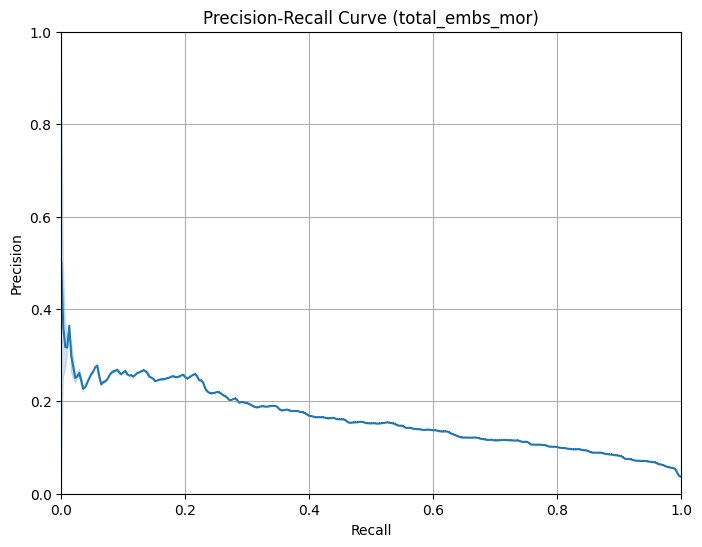

Model saved to ./saved_models

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 10, 'subsample': 0.8}
Best Validation AUPRC: 0.2563

Test Metrics for the Best Model:
AUROC: 0.8668
AUPRC: 0.2174
Precision: 0.2992
Recall: 0.2212
F1: 0.2544
Accuracy: 0.9527
Brier: 0.0378
Precision@Recall_0.8: 0.1261


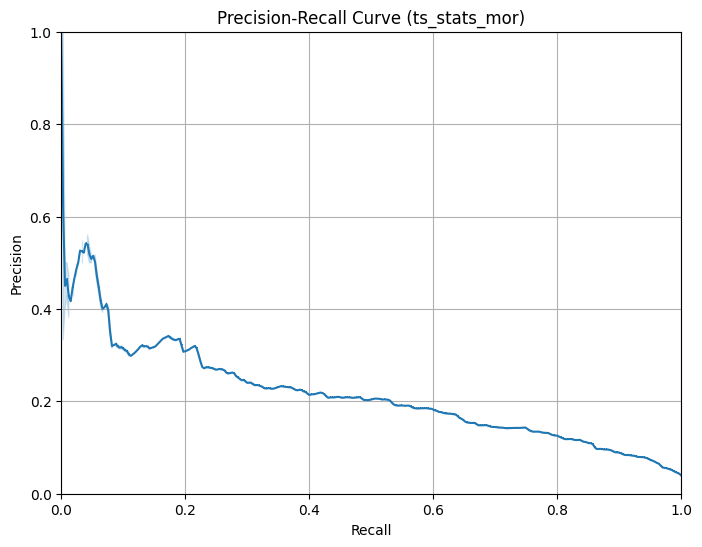

Model saved to ./saved_models

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'scale_pos_weight': 1, 'subsample': 0.8}
Best Validation AUPRC: 0.2045

Test Metrics for the Best Model:
AUROC: 0.8466
AUPRC: 0.1659
Precision: 0.3750
Recall: 0.0194
F1: 0.0368
Accuracy: 0.9641
Brier: 0.0319
Precision@Recall_0.8: 0.0986


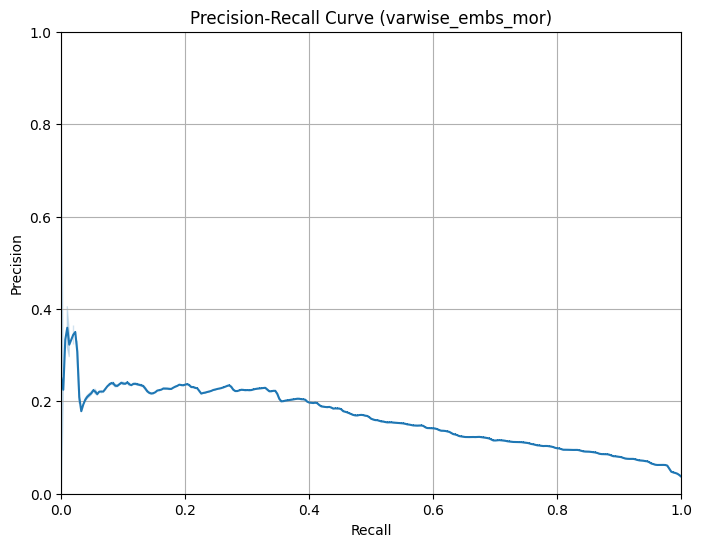

Model saved to ./saved_models

Comparison of Metrics:
Representation 1: {'AUROC': 0.8461625346989566, 'AUPRC': 0.1648964718536622, 'Precision': 0.11616954474097331, 'Recall': 0.7161290322580646, 'F1': 0.19990995047276003, 'Accuracy': 0.7965655409273039, 'Brier': 0.13089495926872752, 'Precision@Recall_0.8': 0.10163934426229508}
Representation 2: {'AUROC': 0.8668144439228778, 'AUPRC': 0.21737005241093763, 'Precision': 0.29918032786885246, 'Recall': 0.22121212121212122, 'F1': 0.25435540069686413, 'Accuracy': 0.9526810392482035, 'Brier': 0.037805877769998095, 'Precision@Recall_0.8': 0.12607449856733524}
Representation 3: {'AUROC': 0.8465906001722983, 'AUPRC': 0.16585957333855383, 'Precision': 0.375, 'Recall': 0.01935483870967742, 'F1': 0.03680981595092025, 'Accuracy': 0.9640526617057813, 'Brier': 0.03189436561491314, 'Precision@Recall_0.8': 0.09860834990059641}


In [12]:
# Evaluate downstream model on REP_1
model_1, params_1, auprc_1, metrics_1 = grid_search_train_and_evaluate_downstream_model(
    train_emb_df,
    valid_emb_df,
    test_emb_df,
    param_grid,
    model_name='total_embs_mor',
    save_path='./saved_models',
    verbose=False
)

# On REP_2 . . .
model_2, params_2, auprc_2, metrics_2 = grid_search_train_and_evaluate_downstream_model(
    train_df,
    valid_df,
    test_df,
    param_grid,
    model_name='ts_stats_mor',
    save_path='./saved_models',
    verbose=False
)

model_3, params_3, auprc_3, metrics_3 = grid_search_train_and_evaluate_downstream_model(
    train_vars_df,
    valid_vars_df,
    test_vars_df,
    param_grid,
    model_name='varwise_embs_mor',
    save_path='./saved_models',
    verbose=False
)

# Compare metrics...
print("\nComparison of Metrics:")
print("Representation 1:", metrics_1)
print("Representation 2:", metrics_2)
print("Representation 3:", metrics_3)

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

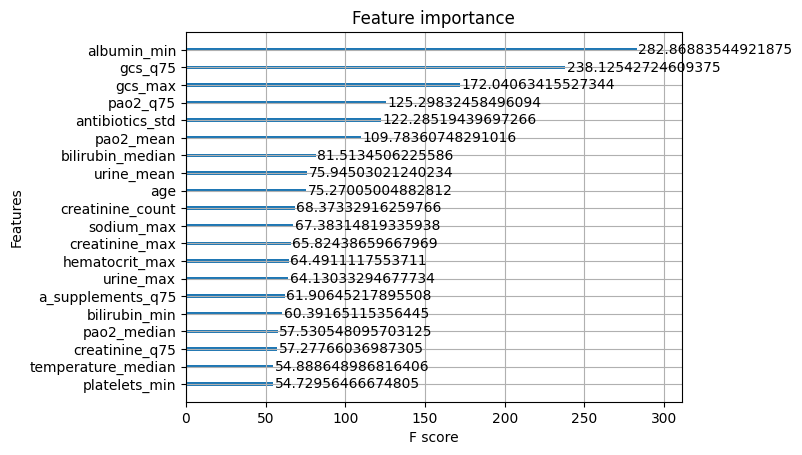

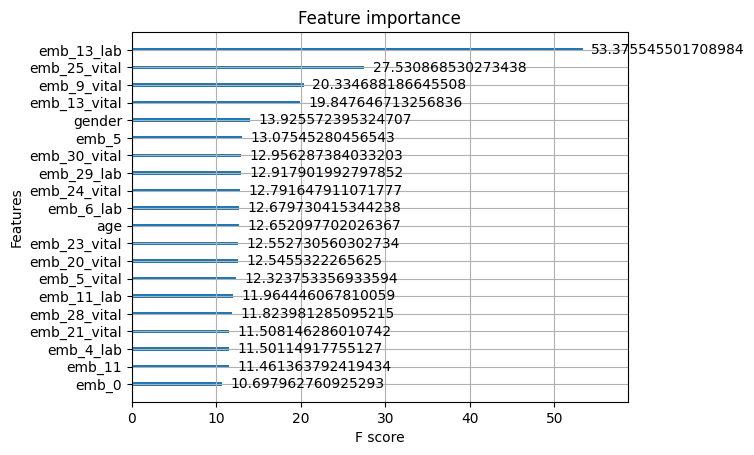

In [13]:
xgb.plot_importance(model_2.get_booster(), importance_type='gain', max_num_features=20)
xgb.plot_importance(model_3.get_booster(), importance_type='gain', max_num_features=20)


Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'scale_pos_weight': 24, 'subsample': 1.0}
Best Validation AUPRC: 0.2077

Test Metrics for the Best Model:
AUROC: 0.8363
AUPRC: 0.1574
Precision: 0.1340
Recall: 0.5677
F1: 0.2169
Accuracy: 0.8545
Brier: 0.0966
Precision@Recall_0.8: 0.1004


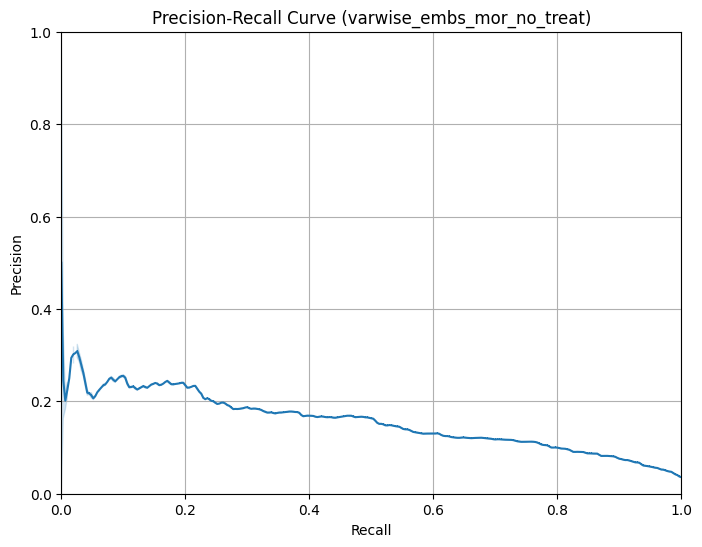

Model saved to ./saved_models

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'scale_pos_weight': 1, 'subsample': 1.0}
Best Validation AUPRC: 0.1395

Test Metrics for the Best Model:
AUROC: 0.7949
AUPRC: 0.1304
Precision: 0.0000
Recall: 0.0000
F1: 0.0000
Accuracy: 0.9644
Brier: 0.0325
Precision@Recall_0.8: 0.0769


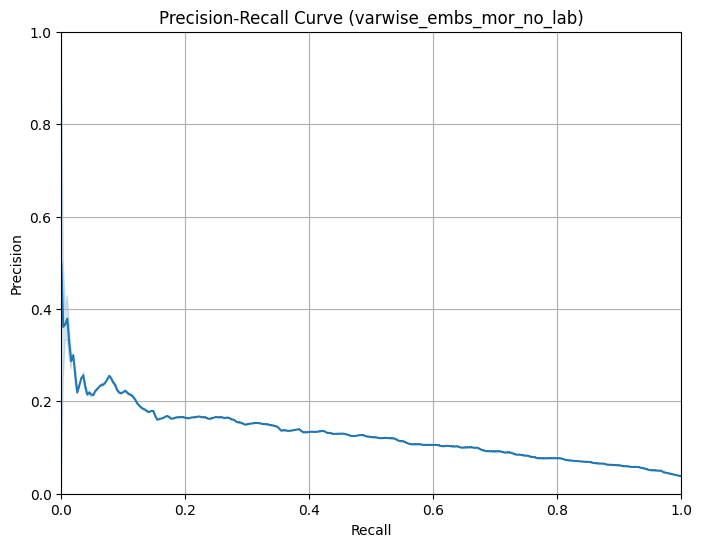

Model saved to ./saved_models

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'scale_pos_weight': 1, 'subsample': 1.0}
Best Validation AUPRC: 0.1377

Test Metrics for the Best Model:
AUROC: 0.7798
AUPRC: 0.1198
Precision: 0.3333
Recall: 0.0065
F1: 0.0127
Accuracy: 0.9643
Brier: 0.0330
Precision@Recall_0.8: 0.0752


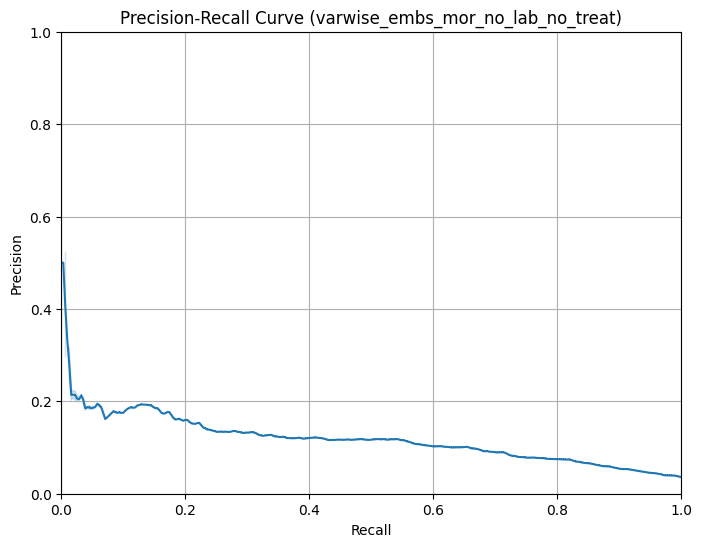

Model saved to ./saved_models

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'scale_pos_weight': 10, 'subsample': 0.8}
Best Validation AUPRC: 0.1617

Test Metrics for the Best Model:
AUROC: 0.8137
AUPRC: 0.1454
Precision: 0.1583
Recall: 0.3581
F1: 0.2196
Accuracy: 0.9097
Brier: 0.0690
Precision@Recall_0.8: 0.0923


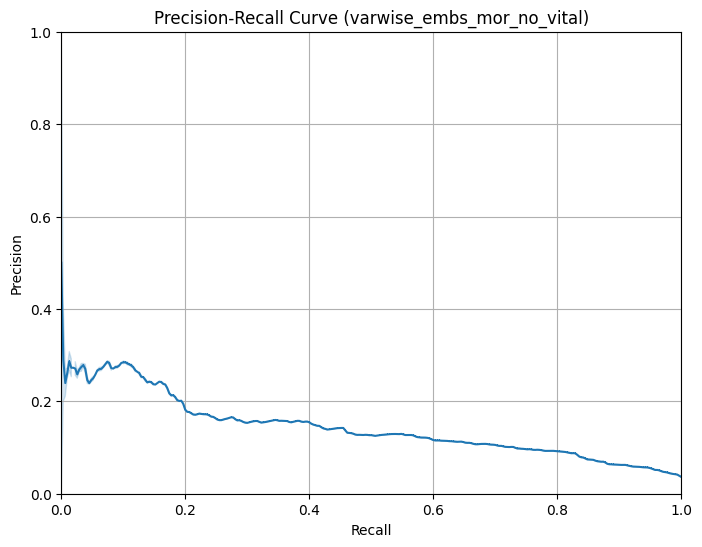

Model saved to ./saved_models
=== Version 4 (no treat) ===
{'AUROC': 0.836305925145975, 'AUPRC': 0.1573634006648848, 'Precision': 0.13404417364813404, 'Recall': 0.567741935483871, 'F1': 0.21688231669747382, 'Accuracy': 0.8544934172867773, 'Brier': 0.09657804958364434, 'Precision@Recall_0.8': 0.10036422501011737}
=== Version 5 (no lab) ===
{'AUROC': 0.7948649373025749, 'AUPRC': 0.13036605084442074, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0, 'Accuracy': 0.964396107613051, 'Brier': 0.03253067937128641, 'Precision@Recall_0.8': 0.07692307692307693}
=== Version 6 (no lab & no treat) ===
{'AUROC': 0.7798395711687565, 'AUPRC': 0.11979902074413404, 'Precision': 0.3333333333333333, 'Recall': 0.0064516129032258064, 'F1': 0.012658227848101266, 'Accuracy': 0.964281625643961, 'Brier': 0.03295036724171211, 'Precision@Recall_0.8': 0.07524932003626474}
=== Version 7 (no vital) ===
{'AUROC': 0.8137088159280177, 'AUPRC': 0.14537375349999196, 'Precision': 0.15834522111269614, 'Recall': 0.3580645161290323

In [14]:
# Version 4: treat 변수 제외
train_vars_no_treat = train_vars_df.drop(columns=var_categories['treat'])
valid_vars_no_treat = valid_vars_df.drop(columns=var_categories['treat'])
test_vars_no_treat  = test_vars_df.drop(columns=var_categories['treat'])

model_v4, params_v4, auprc_v4, metrics_v4 = grid_search_train_and_evaluate_downstream_model(
    train_vars_no_treat,
    valid_vars_no_treat,
    test_vars_no_treat,
    param_grid,
    model_name='varwise_embs_mor_no_treat',
    save_path='./saved_models',
    verbose=False
)

# Version 5: lab 변수 제외
train_vars_no_lab = train_vars_df.drop(columns=var_categories['lab'])
valid_vars_no_lab = valid_vars_df.drop(columns=var_categories['lab'])
test_vars_no_lab  = test_vars_df.drop(columns=var_categories['lab'])

model_v5, params_v5, auprc_v5, metrics_v5 = grid_search_train_and_evaluate_downstream_model(
    train_vars_no_lab,
    valid_vars_no_lab,
    test_vars_no_lab,
    param_grid,
    model_name='varwise_embs_mor_no_lab',
    save_path='./saved_models',
    verbose=False
)

# Version 6: lab와 treat 모두 제외
cols_to_drop = var_categories['lab'] + var_categories['treat']
train_vars_no_lt = train_vars_df.drop(columns=cols_to_drop)
valid_vars_no_lt = valid_vars_df.drop(columns=cols_to_drop)
test_vars_no_lt  = test_vars_df.drop(columns=cols_to_drop)

model_v6, params_v6, auprc_v6, metrics_v6 = grid_search_train_and_evaluate_downstream_model(
    train_vars_no_lt,
    valid_vars_no_lt,
    test_vars_no_lt,
    param_grid,
    model_name='varwise_embs_mor_no_lab_no_treat',
    save_path='./saved_models',
    verbose=False
)

# Version 7: vital 제외
cols_to_drop = var_categories['vital']
train_vars_no_vital = train_vars_df.drop(columns=cols_to_drop)
valid_vars_no_vital = valid_vars_df.drop(columns=cols_to_drop)
test_vars_no_vital  = test_vars_df.drop(columns=cols_to_drop)

model_v7, params_v7, auprc_v7, metrics_v7 = grid_search_train_and_evaluate_downstream_model(
    train_vars_no_vital,
    valid_vars_no_vital,
    test_vars_no_vital,
    param_grid,
    model_name='varwise_embs_mor_no_vital',
    save_path='./saved_models',
    verbose=False
)

# 결과 출력 (예시)
print("=== Version 4 (no treat) ===")
print(metrics_v4)
print("=== Version 5 (no lab) ===")
print(metrics_v5)
print("=== Version 6 (no lab & no treat) ===")
print(metrics_v6)
print("=== Version 7 (no vital) ===")
print(metrics_v7)


Test Metrics for model_3:
AUROC: 0.7022
AUPRC: 0.0783
Precision: 0.1223
Recall: 0.0253
F1: 0.0419
Accuracy: 0.9523
Brier: 0.0449
Precision@Recall_0.8: 0.0655


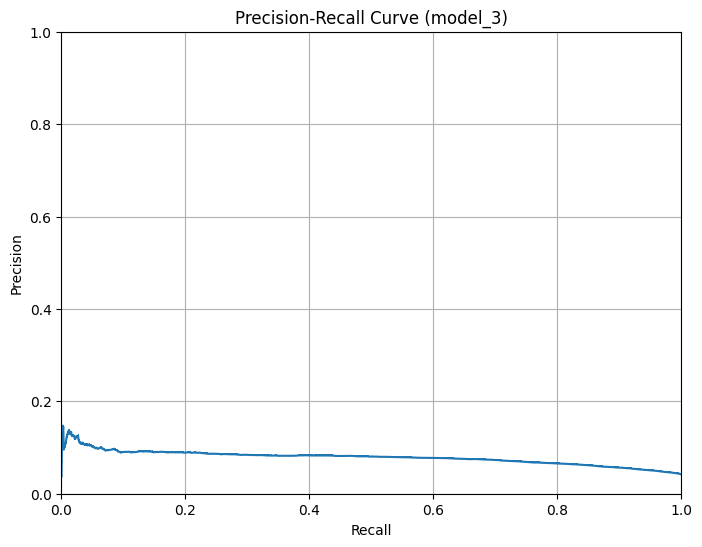

In [15]:
# test_vars_df_eicu의 'outcome' 열은 label, 나머지는 feature로 사용
X_test = test_vars_df_eicu.drop(columns=['outcome'])
y_test = test_vars_df_eicu['outcome']

# model_3로 예측 수행 (model_3는 sklearn wrapper를 사용하는 XGB 모델)
y_pred_proba = model_3.predict_proba(X_test)[:, 1]
y_pred = model_3.predict(X_test)

# 평가 지표 계산
auroc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1_val = f1_score(y_test, y_pred)
accuracy_val = accuracy_score(y_test, y_pred)
brier = brier_score_loss(y_test, y_pred_proba)

# 특정 recall (0.8) 이상인 구간에서의 최대 precision 계산
target_recall = 0.8
precisions, recalls, _ = precision_recall_curve(y_test, y_pred_proba)
if np.any(recalls >= target_recall):
    precision_at_target = np.max(precisions[recalls >= target_recall])
else:
    precision_at_target = np.nan

test_metrics = {
    'AUROC': auroc,
    'AUPRC': auprc,
    'Precision': precision_val,
    'Recall': recall_val,
    'F1': f1_val,
    'Accuracy': accuracy_val,
    'Brier': brier,
    'Precision@Recall_0.8': precision_at_target
}

print("\nTest Metrics for model_3:")
for key, value in test_metrics.items():
    print(f"{key}: {value:.4f}")

# Precision-Recall Curve 그리기 (x, y축 범위를 0~1로 고정)
plt.figure(figsize=(8,6))
sns.lineplot(x=recalls, y=precisions, marker=',')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (model_3)')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.show()

# Explain

In [16]:

# define the causal graph
GRAPH = Graph(
    nodes= list(var_categories.keys()),
    edges=[
        ('static', 'vital'),
        ('static', 'lab'),
        ('vital', 'treat'),
        ('lab', 'treat'),
        ('static', 'treat'),
        ('static', 'outcome'),
        ('vital', 'outcome'), 
        ('lab', 'outcome'), 
        ('treat', 'outcome'), 
    ]
)

train_features = var_categories['static'] + var_categories['lab'] + var_categories['treat'] + var_categories['vital']


In [ ]:
def auprc(model, data, subset_cols=None, weight=None, target_name='outcome'):
    """
    모델의 예측 확률을 사용해 AUPRC (Average Precision Score)를 계산하는 함수.

    Parameters:
      - model: 예측 모델 (predict_proba 메서드가 있어야 함)
      - data: 평가할 DataFrame
      - subset_cols: 사용할 feature 컬럼 리스트 (None이면 전체 데이터 사용)
      - weight: 샘플 가중치 (None이면 가중치 없이 계산)
      - target_name: 타겟 컬럼 이름 (기본값 'Y')

    Returns:
      - AUPRC 값 (float)
    """
    data_input = data[subset_cols] if subset_cols is not None else data
    return average_precision_score(data[target_name], model.predict_proba(data_input)[:, 1], sample_weight=weight)

def brier(model, data, subset_cols = None, weight = None, target_name = 'outcome'):
    data_input = data[subset_cols] if subset_cols is not None else data
    return brier_score_loss(data[target_name], model.predict_proba(data_input)[:, 1], sample_weight = weight)
def compute_metrics_from_embeddings(emb_df: pd.DataFrame, 
                                    target, 
                                    model, 
                                    device='cuda'):
    """
    이미 계산된 임베딩 DataFrame을 입력받아, STraTS 모델의 마지막 prediction head (linear_death)
    를 통해 예측 확률을 계산하고, 여러 분류 지표(metric)를 산출하는 함수.
    
    Parameters:
      - emb_df: DataFrame, shape (n_samples, embed_dim), 각 행이 하나의 임베딩
      - target: 실제 라벨 (numpy array 또는 list, shape (n_samples,)), 이진 (0,1)
      - model: 이미 학습된 STraTS 모델 인스턴스, linear_death head가 포함되어 있음
      - device: 'cuda' 또는 'cpu'
    
    Returns:
      - metrics: dict, 여러 metric (AUROC, AUPRC, Precision, Recall, F1, Accuracy, Brier, Precision@Recall_0.8)
    """
    model.eval()
    # DataFrame의 값 (n_samples x embed_dim) -> tensor, shape: (n_samples, embed_dim)
    embeddings = torch.tensor(emb_df.values, dtype=torch.float32).to(device)
    
    with torch.no_grad():
        # 모델의 마지막 prediction head를 사용하여 예측 logits 계산
        # linear_death의 입력은 최종 임베딩
        logits = model.linear_death(embeddings)  # shape: (n_samples, 1)
        probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()  # 예측 확률
    
    # 이진 분류의 예측 결과 (0/1)
    y_pred = (probs >= 0.5).astype(int)
    y_true = np.array(target)
    
    # 각 metric 계산
    auroc = roc_auc_score(y_true, probs)
    auprc = average_precision_score(y_true, probs)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    brier = brier_score_loss(y_true, probs)
    
    # 특정 recall 수준(예: 0.8)에서의 최대 precision 계산
    target_recall = 0.8
    precisions, recalls, _ = precision_recall_curve(y_true, probs)
    if np.any(recalls >= target_recall):
        precision_at_target = np.max(precisions[recalls >= target_recall])
    else:
        precision_at_target = np.nan
    
    metrics = {
        'AUROC': auroc,
        'AUPRC': auprc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Accuracy': accuracy,
        'Brier': brier,
        'Precision@Recall_0.8': precision_at_target
    }
    
    return metrics

In [18]:
train_features = ['emb_0_vital', 'emb_1_vital', 'emb_2_vital', 'emb_3_vital', 'emb_4_vital', 'emb_5_vital',
                'emb_6_vital', 'emb_7_vital', 'emb_8_vital', 'emb_9_vital', 'emb_10_vital', 'emb_11_vital',
                'emb_12_vital', 'emb_13_vital', 'emb_14_vital', 'emb_15_vital', 'emb_16_vital', 'emb_17_vital',
                'emb_18_vital', 'emb_19_vital', 'emb_20_vital', 'emb_21_vital', 'emb_22_vital', 'emb_23_vital',
                'emb_24_vital', 'emb_25_vital', 'emb_26_vital', 'emb_27_vital', 'emb_28_vital', 'emb_29_vital',
                'emb_30_vital', 'emb_31_vital', 'emb_0_lab', 'emb_1_lab', 'emb_2_lab', 'emb_3_lab', 'emb_4_lab',
                'emb_5_lab', 'emb_6_lab', 'emb_7_lab', 'emb_8_lab', 'emb_9_lab', 'emb_10_lab', 'emb_11_lab', 
                'emb_12_lab', 'emb_13_lab', 'emb_14_lab', 'emb_15_lab', 'emb_16_lab', 'emb_17_lab', 'emb_18_lab', 
                'emb_19_lab', 'emb_20_lab', 'emb_21_lab', 'emb_22_lab', 'emb_23_lab', 'emb_24_lab', 'emb_25_lab', 
                'emb_26_lab', 'emb_27_lab', 'emb_28_lab', 'emb_29_lab', 'emb_30_lab', 'emb_31_lab', 'emb_0', 'emb_1', 
                'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7', 'emb_8', 'emb_9', 'emb_10', 'emb_11', 'emb_12', 
                'emb_13', 'emb_14', 'emb_15', 'emb_16', 'emb_17', 'emb_18', 'emb_19', 'emb_20', 'emb_21', 'emb_22', 'emb_23', 
                'emb_24', 'emb_25', 'emb_26', 'emb_27', 'emb_28', 'emb_29', 'emb_30', 'emb_31', 'age', 'height', 'gender']

In [19]:
exp = CGExplainerDR(GRAPH, train_vars_df, test_vars_df, train_vars_df_eicu, valid_vars_df_eicu,
        train_features, var_categories, target_name = 'outcome'
)

In [20]:
perfs = exp.get_perf_on_sets(model_3, metric = auprc)
perfs

{'source': 0.16585957333855383, 'target': 0.08111124169822395}

In [21]:
exp.get_all_possible_shifts()


['static',
 (frozenset({'static'}), 'lab'),
 (frozenset({'lab', 'static', 'vital'}), 'treat'),
 (frozenset({'static'}), 'vital'),
 (frozenset({'lab', 'static', 'treat', 'vital'}), 'outcome')]

In [22]:
res_auprc = exp.explain(model_3, metric = auprc)
res_auprc

Evaluate set function: 32it [00:10,  2.98it/s]


P(static)                              0.036517
P(lab | static)                       -0.005610
P(treat | lab,static,vital)            0.397903
P(vital | static)                      0.266194
P(outcome | lab,static,treat,vital)   -0.058299
dtype: float64

In [23]:
exp.scale(res_auprc, perfs)

P(static)                             -0.004861
P(lab | static)                        0.000747
P(treat | lab,static,vital)           -0.052963
P(vital | static)                     -0.035432
P(outcome | lab,static,treat,vital)    0.007760
dtype: float64

In [24]:
perfs = exp.get_perf_on_sets(model_3, metric = brier)
perfs

{'source': 0.03189436561491314, 'target': 0.046671551964665436}

In [25]:
res_brier = exp.explain(model_3, metric = brier)
res_brier

Evaluate set function: 32it [00:00, 171.64it/s]


P(static)                             -0.010581
P(lab | static)                       -0.016864
P(treat | lab,static,vital)            0.029196
P(vital | static)                      0.003952
P(outcome | lab,static,treat,vital)   -0.016173
dtype: float64

In [26]:
exp.scale(res_brier, perfs)

P(static)                              0.014934
P(lab | static)                        0.023801
P(treat | lab,static,vital)           -0.041206
P(vital | static)                     -0.005578
P(outcome | lab,static,treat,vital)    0.022826
dtype: float64